In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
print("Done")

Done


In [3]:
planets_data = pd.read_csv("PSCD.csv",sep=None,
    engine="python",
    comment="#")

In [4]:
planets_data.shape

(6319, 325)

In [5]:
planets_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6319 entries, 0 to 6318
Columns: 325 entries, rowid to pl_nobs_jwst_pc
dtypes: float64(239), int64(6), str(80)
memory usage: 52.7 MB


In [6]:
planets_data.describe()

,rowid,sy_snum,sy_pnum,sy_mnum,cb_flag,disc_year,rv_flag,pul_flag,ptv_flag,tran_flag,...,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_nobs_jwst_tran,pl_nobs_jwst_e,pl_nobs_jwst_pc
count,6319.000000,6319.000000,6319.000000,6319.0,6319.000000,6319.000000,6314.000000,6314.000000,6314.000000,6314.000000,...,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000,6292.000000
mean,3160.000000,1.101282,1.760880,0.0,0.008546,2017.225827,0.392936,0.001267,0.000317,0.744378,...,0.862365,0.343929,0.197552,0.174189,0.120470,0.135092,0.013350,0.083598,0.028767,0.005880
std,1824.282507,0.339259,1.152072,0.0,0.092054,5.106041,0.488442,0.035576,0.017796,0.436245,...,1.158741,2.373077,0.859133,0.901357,1.235868,1.219847,0.276476,0.705366,0.437074,0.095005
min,1.000000,1.000000,1.000000,0.0,0.000000,1992.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1580.500000,1.000000,1.000000,0.0,0.000000,2014.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3160.000000,1.000000,1.000000,0.0,0.000000,2016.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4739.500000,1.000000,2.000000,0.0,0.000000,2021.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6319.000000,4.000000,8.000000,0.0,1.000000,2026.000000,1.000000,1.000000,1.000000,1.000000,...,16.000000,70.000000,12.000000,13.000000,37.000000,33.000000,10.000000,20.000000,15.000000,3.000000


In [7]:
planets_data.isna().sum()

rowid                   0
pl_name                 0
hostname                0
pl_letter               0
hd_name              5267
                     ... 
pl_ntranspec           27
pl_ndispec             27
pl_nobs_jwst_tran      27
pl_nobs_jwst_e         27
pl_nobs_jwst_pc        27
Length: 325, dtype: int64

In [8]:
planets_data["pl_name"]

0         11 Com b
1         11 UMi b
2         14 And b
3         14 Her b
4       16 Cyg B b
           ...    
6314     ups And b
6315     ups And c
6316     ups And d
6317     ups Leo b
6318      xi Aql b
Name: pl_name, Length: 6319, dtype: str

In [9]:
relevant_cols = [
    'pl_name', 'hostname',
    'pl_orbper', 'pl_orbsmax',
    'pl_rade', 'pl_bmasse',
    'pl_insol', 'pl_eqt',
    'st_teff', 'st_rad', 'st_mass', 'st_spectype',
    'sy_dist', 'disc_year', 'discoverymethod'
]
relevant_cols

['pl_name',
 'hostname',
 'pl_orbper',
 'pl_orbsmax',
 'pl_rade',
 'pl_bmasse',
 'pl_insol',
 'pl_eqt',
 'st_teff',
 'st_rad',
 'st_mass',
 'st_spectype',
 'sy_dist',
 'disc_year',
 'discoverymethod']

In [10]:
[col for col in relevant_cols if col not in planets_data.columns]

[]

In [11]:
relevant_planets_data = planets_data[relevant_cols].copy()

In [12]:
relevant_planets_data

,pl_name,hostname,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_spectype,sy_dist,disc_year,discoverymethod
0,11 Com b,11 Com,323.210000,1.178000,12.2,4914.898486,68.5387,803.26,4874.00,13.76,2.09,G8 III,93.1846,2007,Radial Velocity
1,11 UMi b,11 UMi,516.219970,1.530000,12.3,4684.814200,114.8502,896.43,4213.00,29.79,2.78,K4 III,125.3210,2009,Radial Velocity
2,14 And b,14 And,186.760000,0.775000,13.1,1131.151301,115.1634,909.92,4888.00,11.55,1.78,K0 III,75.4392,2008,Radial Velocity
3,14 Her b,14 Her,1766.410000,2.839000,12.5,2828.672822,0.0873,147.32,5338.00,0.93,0.97,K0,17.9323,2002,Radial Velocity
4,16 Cyg B b,16 Cyg B,798.500000,1.660000,13.5,565.737400,0.4540,228.76,5750.00,1.13,1.08,G3 V,21.1397,1996,Radial Velocity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6314,ups And b,ups And,4.617033,0.059222,14.0,218.531000,955.9835,1523.73,6156.77,1.56,1.30,F8 V,13.4054,1996,Radial Velocity
6315,ups And c,ups And,241.258000,0.827774,12.3,4443.241130,4.8931,407.56,6156.77,1.56,1.30,F8 V,13.4054,1999,Radial Velocity
6316,ups And d,ups And,1276.460000,2.513290,12.5,3257.741172,0.5308,233.90,6156.77,1.56,1.30,F8 V,13.4054,1999,Radial Velocity
6317,ups Leo b,ups Leo,385.200000,1.180000,14.2,162.092488,45.3174,719.08,4836.00,11.22,1.48,G9 III,52.5973,2021,Radial Velocity


In [13]:
relevant_planets_data.isna().sum().sort_values(ascending=False)

st_spectype        3991
pl_insol            592
pl_eqt              536
pl_orbsmax          439
pl_orbper           348
st_rad              343
st_teff             317
pl_rade              60
sy_dist              54
pl_bmasse            41
st_mass              32
pl_name               0
hostname              0
disc_year             0
discoverymethod       0
dtype: int64

In [14]:
relevant_planets_data.shape

(6319, 15)

In [15]:
relevant_planets_data.head()

,pl_name,hostname,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_spectype,sy_dist,disc_year,discoverymethod
0,11 Com b,11 Com,323.21000,1.178,12.2,4914.898486,68.5387,803.26,4874.0,13.76,2.09,G8 III,93.1846,2007,Radial Velocity
1,11 UMi b,11 UMi,516.21997,1.530,12.3,4684.814200,114.8502,896.43,4213.0,29.79,2.78,K4 III,125.3210,2009,Radial Velocity
2,14 And b,14 And,186.76000,0.775,13.1,1131.151301,115.1634,909.92,4888.0,11.55,1.78,K0 III,75.4392,2008,Radial Velocity
3,14 Her b,14 Her,1766.41000,2.839,12.5,2828.672822,0.0873,147.32,5338.0,0.93,0.97,K0,17.9323,2002,Radial Velocity
4,16 Cyg B b,16 Cyg B,798.50000,1.660,13.5,565.737400,0.4540,228.76,5750.0,1.13,1.08,G3 V,21.1397,1996,Radial Velocity


In [16]:
relevant_planets_data = relevant_planets_data.dropna(subset=['pl_insol', 'pl_eqt'], how='all')
relevant_planets_data.shape

(5789, 15)

In [17]:
relevant_planets_data.isna().sum().sort_values(ascending=False)

st_spectype        3568
pl_orbsmax          202
pl_orbper            70
pl_insol             62
pl_rade              39
sy_dist              38
st_rad               35
pl_bmasse            27
st_teff              22
st_mass              19
pl_eqt                6
pl_name               0
hostname              0
disc_year             0
discoverymethod       0
dtype: int64

In [18]:
relevant_planets_data = relevant_planets_data.dropna(subset=['pl_orbper', 'st_teff', 'st_rad', 'st_mass', 'pl_rade', 'sy_dist', 'pl_bmasse'])
relevant_planets_data.shape 

(5613, 15)

In [19]:
relevant_planets_data.isna().sum().sort_values(ascending=False)

st_spectype        3494
pl_orbsmax          200
pl_insol             47
pl_orbper             0
hostname              0
pl_rade               0
pl_name               0
pl_bmasse             0
pl_eqt                0
st_rad                0
st_teff               0
st_mass               0
sy_dist               0
disc_year             0
discoverymethod       0
dtype: int64

In [20]:
missing_pl_insol=relevant_planets_data['pl_insol'].isna()

#calculatin missing values using Stefan-Boltzmann law — temperature scales as flux to the 1/4 power:

relevant_planets_data.loc[missing_pl_insol, 'pl_insol'] = (relevant_planets_data.loc[missing_pl_insol, 'pl_eqt'] / 255) ** 4

In [21]:
#calculating orbsmax using Keplar's third law: a³ = P² × M_star (when a is in AU, P in years, mass in solar masses), pl_orbper and st_mass mostly known data
missing_pl_orbsmax = relevant_planets_data['pl_orbsmax'].isna()
period_years = relevant_planets_data.loc[missing_pl_orbsmax, 'pl_orbper'] / 365.25
relevant_planets_data.loc[missing_pl_orbsmax, 'pl_orbsmax'] = (period_years**2 * relevant_planets_data.loc[missing_pl_orbsmax, 'st_mass']) ** (1/3)

In [22]:
relevant_planets_data.isna().sum()


pl_name               0
hostname              0
pl_orbper             0
pl_orbsmax            0
pl_rade               0
pl_bmasse             0
pl_insol              0
pl_eqt                0
st_teff               0
st_rad                0
st_mass               0
st_spectype        3494
sy_dist               0
disc_year             0
discoverymethod       0
dtype: int64

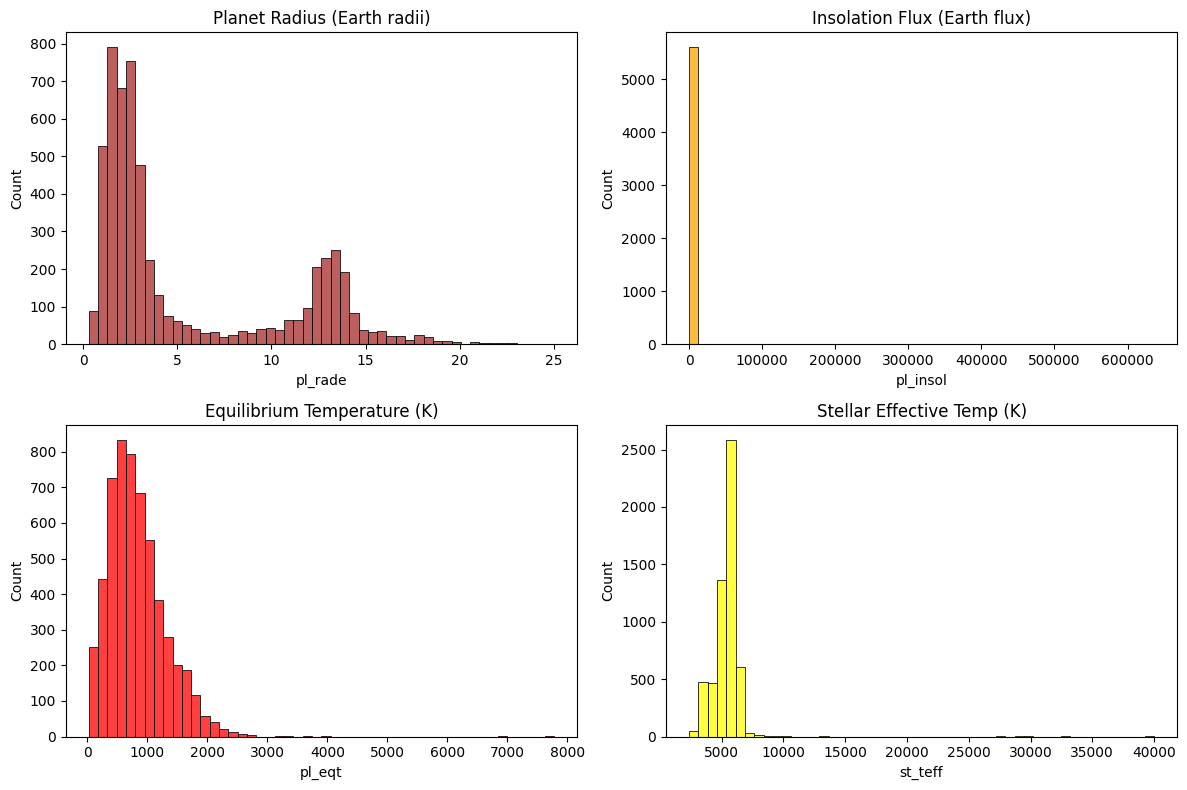

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(relevant_planets_data['pl_rade'], bins=50, ax=axes[0,0], color="brown")
axes[0,0].set_title('Planet Radius (Earth radii)')

sns.histplot(relevant_planets_data['pl_insol'], bins=50, ax=axes[0,1], color="orange")
axes[0,1].set_title('Insolation Flux (Earth flux)')

sns.histplot(relevant_planets_data['pl_eqt'], bins=50, ax=axes[1,0], color="red")
axes[1,0].set_title('Equilibrium Temperature (K)')

sns.histplot(relevant_planets_data['st_teff'], bins=50, ax=axes[1,1], color="yellow")
axes[1,1].set_title('Stellar Effective Temp (K)')

plt.tight_layout()
plt.show()

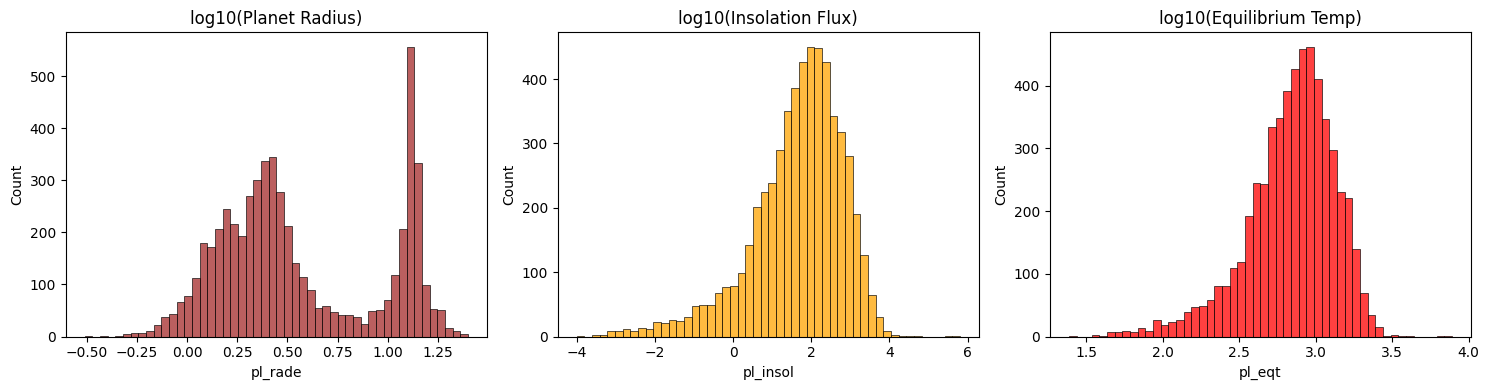

In [24]:
#using log transform to stabilize the right skewed values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(np.log10(relevant_planets_data['pl_rade']), bins=50, ax=axes[0], color='brown')
axes[0].set_title('log10(Planet Radius)')

sns.histplot(np.log10(relevant_planets_data['pl_insol']), bins=50, ax=axes[1],color='orange')
axes[1].set_title('log10(Insolation Flux)')

sns.histplot(np.log10(relevant_planets_data['pl_eqt']), bins=50, ax=axes[2],color='red')
axes[2].set_title('log10(Equilibrium Temp)')

plt.tight_layout()
plt.show()

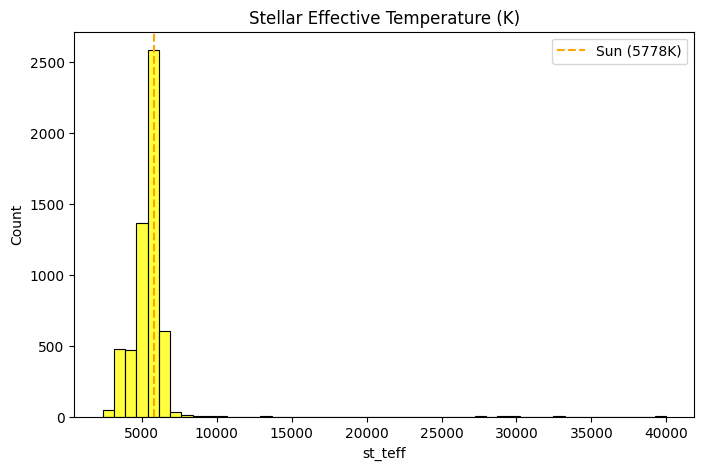

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(relevant_planets_data['st_teff'], bins=50, color="yellow")
plt.title('Stellar Effective Temperature (K)')
plt.axvline(5778, color='orange', linestyle='--', label='Sun (5778K)')
plt.legend()
plt.show()

In [26]:
def classify_star(teff):
    if teff >= 7500:
        return 'A (hot)'
    elif teff >= 6000:
        return 'F'
    elif teff >= 5200:
        return 'G (Sun-like)'
    elif teff >= 3700:
        return 'K'
    else:
        return 'M (red dwarf)'

relevant_planets_data['star_class'] = relevant_planets_data['st_teff'].apply(classify_star)
relevant_planets_data['star_class'].value_counts()

star_class
G (Sun-like)     2577
K                1578
F                1055
M (red dwarf)     374
A (hot)            29
Name: count, dtype: int64

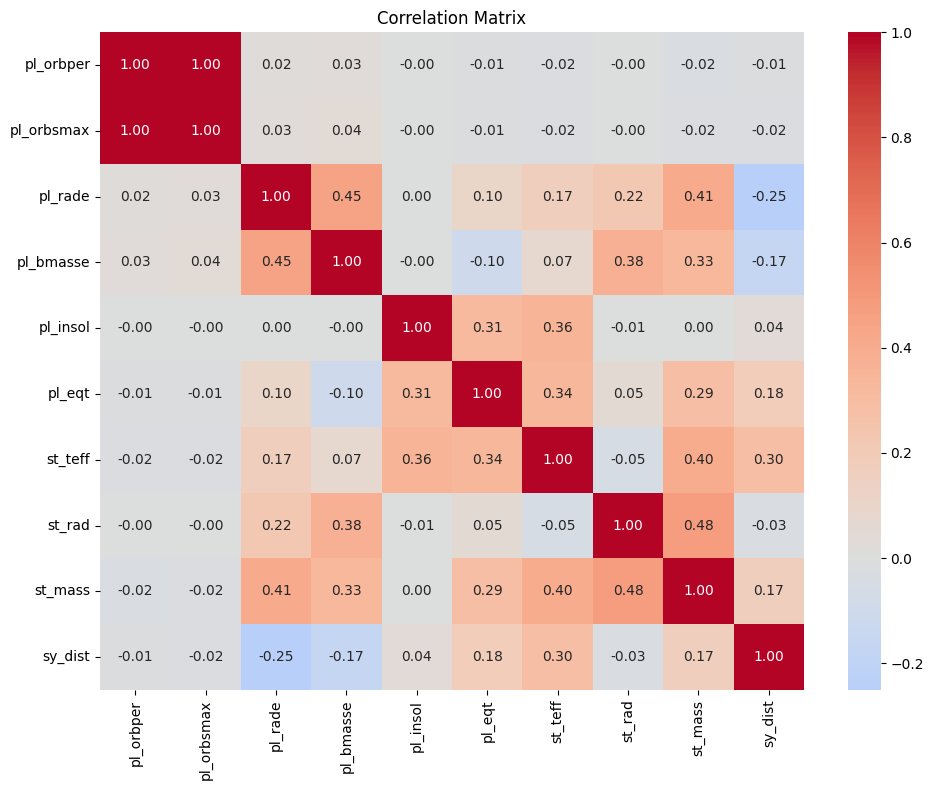

In [27]:
#correlation/pairwise relationships (e.g. does insolation actually track with orbit distance like physics predicts, does planet radius relate to mass in the way we'd expect)
corr_cols = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_insol', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'sy_dist']

plt.figure(figsize=(10, 8))
sns.heatmap(relevant_planets_data[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

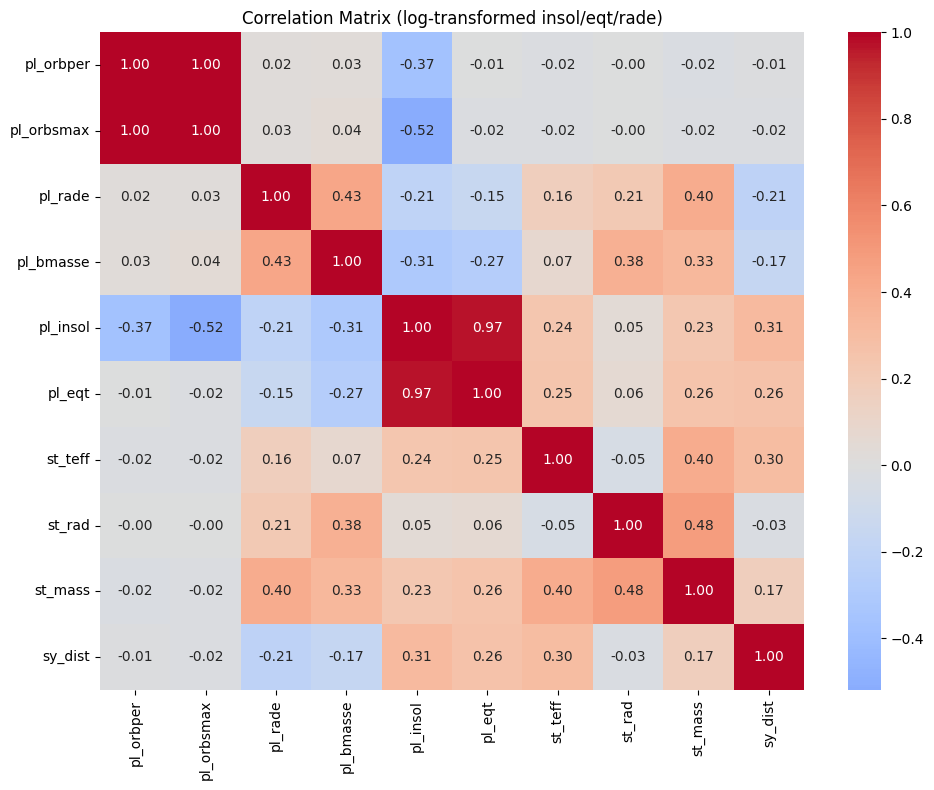

In [28]:
log_corr_data = relevant_planets_data[corr_cols].copy()
log_corr_data['pl_insol'] = np.log10(log_corr_data['pl_insol'])
log_corr_data['pl_eqt'] = np.log10(log_corr_data['pl_eqt'])
log_corr_data['pl_rade'] = np.log10(log_corr_data['pl_rade'])

plt.figure(figsize=(10, 8))
sns.heatmap(log_corr_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (log-transformed insol/eqt/rade)')
plt.tight_layout()
plt.show()

In [29]:
# Layer 1: Earth Similarity Index (ESI) — baseline score

def esi_component(value, earth_value, weight):
    return (1 - abs((value - earth_value) / (value + earth_value))) ** weight

# Using pl_rade (radius) and pl_insol (flux) — the two most standard ESI inputs
radius_esi = esi_component(relevant_planets_data['pl_rade'], 1.0, weight=0.57)
insol_esi = esi_component(relevant_planets_data['pl_insol'], 1.0, weight=0.7)

relevant_planets_data['esi'] = (radius_esi * insol_esi) ** (1/2)

In [30]:
# Layer 2: Habitable zone gate

relevant_planets_data['in_habitable_zone'] = relevant_planets_data['pl_insol'].between(0.35, 1.1)

In [31]:
# Layer 3: Rocky-planet gate

relevant_planets_data['is_rocky_candidate'] = relevant_planets_data['pl_rade'] < 1.75

In [32]:
# Layer 4: Superhabitability bonus

def superhabitability_bonus(row):
    bonus = 0
    if row['star_class'] == 'K':
        bonus += 0.05          # longer stellar lifetime, more stable
    if 1.0 < row['pl_rade'] <= 1.5:
        bonus += 0.05          # larger = more likely to retain atmosphere/geological activity
    return bonus

relevant_planets_data['superhabitability_bonus'] = relevant_planets_data.apply(superhabitability_bonus, axis=1)
relevant_planets_data['final_score'] = relevant_planets_data['esi'] + relevant_planets_data['superhabitability_bonus']

In [33]:
# Layer 5: Final binary label for classifier

relevant_planets_data['is_habitable_candidate'] = (
    relevant_planets_data['in_habitable_zone'] &
    relevant_planets_data['is_rocky_candidate']
)

In [34]:
relevant_planets_data['esi'].describe()

count    5613.000000
mean        0.276285
std         0.182345
min         0.000000
25%         0.139256
50%         0.229229
75%         0.375328
max         0.979449
Name: esi, dtype: float64

In [35]:
relevant_planets_data['in_habitable_zone'].value_counts()

in_habitable_zone
False    5430
True      183
Name: count, dtype: int64

In [36]:
relevant_planets_data['is_rocky_candidate'].value_counts()

is_rocky_candidate
False    4279
True     1334
Name: count, dtype: int64

In [37]:
relevant_planets_data['is_habitable_candidate'].value_counts()

is_habitable_candidate
False    5592
True       21
Name: count, dtype: int64

In [38]:
habitable_planets_data = relevant_planets_data.sort_values('final_score', ascending=False)[['pl_name', 'hostname', 'star_class', 'pl_rade', 'pl_insol', 'esi', 'final_score']].head(21)

In [39]:
habitable_planets_data

,pl_name,hostname,star_class,pl_rade,pl_insol,esi,final_score
6028,Teegarden's Star b,Teegarden's Star,M (red dwarf),1.050,1.080,0.979449,1.029449
4141,Kepler-438 b,Kepler-438,K,1.120,1.400,0.922729,1.022729
5946,TOI-700 d,TOI-700,M (red dwarf),1.073,0.850,0.960970,1.010970
268,GJ 3378 b,GJ 3378,M (red dwarf),1.320,0.910,0.942525,0.992525
2857,Kepler-1512 b,Kepler-1512,K,1.180,1.600,0.890130,0.990130
3041,Kepler-1649 c,Kepler-1649,M (red dwarf),1.060,0.750,0.939529,0.989529
4932,LP 890-9 c,LP 890-9,M (red dwarf),1.367,0.906,0.936396,0.986396
4146,Kepler-442 b,Kepler-442,K,1.340,0.660,0.882531,0.982531
1901,K2-72 e,K2-72,M (red dwarf),1.290,1.200,0.930578,0.980578
1721,K2-3 d,K2-3,K,1.458,1.440,0.879532,0.979532


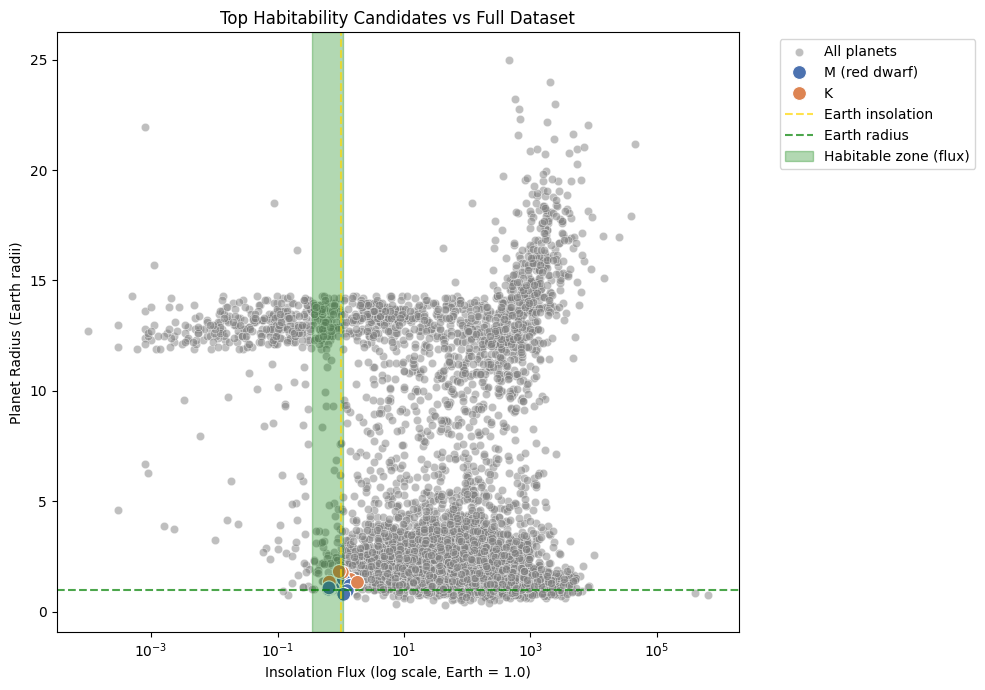

In [40]:
plt.figure(figsize=(10, 7))

# All planets in grey as background context
sns.scatterplot(data=relevant_planets_data, x='pl_insol', y='pl_rade', 
                 color='grey', alpha=0.5, label='All planets')

# top 21
sns.scatterplot(data=habitable_planets_data, x='pl_insol', y='pl_rade', 
                 hue=relevant_planets_data.loc[habitable_planets_data.index, 'star_class'],
                 s=100, palette='deep')

# Reference lines for context
plt.axvline(1.0, color='gold', linestyle='--', alpha=0.7, label='Earth insolation')
plt.axhline(1.0, color='green', linestyle='--', alpha=0.7, label='Earth radius')
plt.axvspan(0.35, 1.1, alpha=0.3, color='green', label='Habitable zone (flux)')

plt.xscale('log')
plt.xlabel('Insolation Flux (log scale, Earth = 1.0)')
plt.ylabel('Planet Radius (Earth radii)')
plt.title('Top Habitability Candidates vs Full Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
feature_cols = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_insol', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass']
X = relevant_planets_data[feature_cols]
Y = relevant_planets_data['final_score']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Forest (primary model)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, Y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_preds))
rf_mae = mean_absolute_error(Y_test, rf_preds)
rf_r2 = r2_score(Y_test, rf_preds)

print("Random Forest — RMSE:", rf_rmse, "MAE:", rf_mae, "R²:", rf_r2)

# Linear Regression (baseline comparison)
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(Y_test, lr_preds))
lr_mae = mean_absolute_error(Y_test, lr_preds)
lr_r2 = r2_score(Y_test, lr_preds)

print("Linear Regression — RMSE:", lr_rmse, "MAE:", lr_mae, "R²:", lr_r2)

Random Forest — RMSE: 0.01251545319447643 MAE: 0.007080690581661566 R²: 0.995608244707973
Linear Regression — RMSE: 2.26267654858378 MAE: 0.15372515665628966 R²: -142.54561286275037


In [44]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

pl_insol      0.862715
pl_rade       0.111670
st_teff       0.009827
pl_eqt        0.009037
pl_bmasse     0.003465
st_rad        0.001112
pl_orbper     0.000791
st_mass       0.000715
pl_orbsmax    0.000668
dtype: float64

In [45]:
indirect_features = ['pl_orbper', 'pl_bmasse', 'st_teff', 'st_mass', 'sy_dist', 'disc_year']

In [46]:
X_indirect = relevant_planets_data[indirect_features]
Y_indirect = relevant_planets_data['final_score']

X_train_i, X_test_i, Y_train_i, Y_test_i = train_test_split(X_indirect, Y_indirect, test_size=0.2, random_state=42)

rf_indirect = RandomForestRegressor(n_estimators=200, random_state=42)
rf_indirect.fit(X_train_i, Y_train_i)
preds_indirect = rf_indirect.predict(X_test_i)

rmse_i = np.sqrt(mean_squared_error(Y_test_i, preds_indirect))
mae_i = mean_absolute_error(Y_test_i, preds_indirect)
r2_i = r2_score(Y_test_i, preds_indirect)

print("Indirect-feature Random Forest — RMSE:", rmse_i, "MAE:", mae_i, "R²:", r2_i)

Indirect-feature Random Forest — RMSE: 0.04684322964311042 MAE: 0.03165355736342914 R²: 0.938476840139693


In [47]:
importances_indirect = pd.Series(rf_indirect.feature_importances_, index=indirect_features).sort_values(ascending=False)
importances_indirect

pl_orbper    0.468653
st_mass      0.262841
st_teff      0.164674
pl_bmasse    0.083260
sy_dist      0.013263
disc_year    0.007309
dtype: float64

In [48]:
indirect_features_v2 = ['pl_orbper', 'pl_bmasse', 'st_teff', 'sy_dist', 'disc_year']

X_indirect2 = relevant_planets_data[indirect_features_v2]
X_train_i2, X_test_i2, Y_train_i2, Y_test_i2 = train_test_split(X_indirect2, Y_indirect, test_size=0.2, random_state=42)

rf_indirect2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_indirect2.fit(X_train_i2, Y_train_i2)
preds_indirect2 = rf_indirect2.predict(X_test_i2)

print("R²:", r2_score(Y_test_i2, preds_indirect2))
print("RMSE:", np.sqrt(mean_squared_error(Y_test_i2, preds_indirect2)))

importances_v2 = pd.Series(rf_indirect2.feature_importances_, index=indirect_features_v2).sort_values(ascending=False)
importances_v2

R²: 0.9171396013525905
RMSE: 0.05436270056119382


pl_orbper    0.456775
st_teff      0.364120
pl_bmasse    0.150035
sy_dist      0.018841
disc_year    0.010228
dtype: float64

In [49]:
indirect_features_v3 = ['pl_bmasse', 'st_teff', 'sy_dist', 'disc_year']

X_indirect3 = relevant_planets_data[indirect_features_v3]
X_train_i3, X_test_i3, Y_train_i3, Y_test_i3 = train_test_split(X_indirect3, Y_indirect, test_size=0.2, random_state=42)

rf_indirect3 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_indirect3.fit(X_train_i3, Y_train_i3)
preds_indirect3 = rf_indirect3.predict(X_test_i3)

print("R²:", r2_score(Y_test_i3, preds_indirect3))
print("RMSE:", np.sqrt(mean_squared_error(Y_test_i3, preds_indirect3)))

importances_v3 = pd.Series(rf_indirect3.feature_importances_, index=indirect_features_v3).sort_values(ascending=False)
importances_v3

R²: 0.45249421715112514
RMSE: 0.13974036363380798


st_teff      0.417911
pl_bmasse    0.290999
sy_dist      0.197106
disc_year    0.093985
dtype: float64

In [50]:
# Predict indirect-model score for ALL planets (not just the test set)
relevant_planets_data['predicted_score_indirect'] = rf_indirect2.predict(
    relevant_planets_data[indirect_features_v2]
)

# Planets NOT flagged by strict filter, but scoring high on indirect model
held_out_candidates = relevant_planets_data[
    ~relevant_planets_data['is_habitable_candidate']
].sort_values('predicted_score_indirect', ascending=False)

held_out_candidates[['pl_name', 'hostname', 'star_class', 'pl_rade', 'pl_insol', 
                       'final_score', 'predicted_score_indirect']].head(15)

,pl_name,hostname,star_class,pl_rade,pl_insol,final_score,predicted_score_indirect
1901,K2-72 e,K2-72,M (red dwarf),1.290,1.200,0.980578,0.948561
1721,K2-3 d,K2-3,K,1.458,1.440,0.979532,0.945334
5947,TOI-700 e,TOI-700,M (red dwarf),0.953,1.270,0.950028,0.937313
214,GJ 1061 c,GJ 1061,M (red dwarf),1.190,1.400,0.964226,0.934710
2720,Kepler-1410 b,Kepler-1410,K,1.780,1.060,0.951048,0.922688
3752,Kepler-283 c,Kepler-283,K,1.820,0.949,0.948343,0.917095
5173,Ross 128 b,Ross 128,M (red dwarf),1.110,1.380,0.976684,0.909191
2675,Kepler-138 e,Kepler-138,K,0.797,1.730,0.916695,0.907208
4141,Kepler-438 b,Kepler-438,K,1.120,1.400,1.022729,0.906313
4144,Kepler-440 b,Kepler-440,K,1.860,1.200,0.923458,0.901930


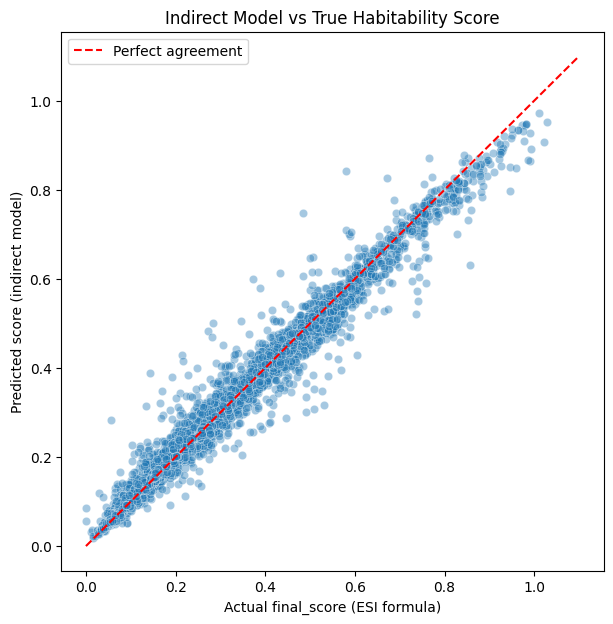

In [51]:
plt.figure(figsize=(7,7))
sns.scatterplot(data=relevant_planets_data, x='final_score', y='predicted_score_indirect', alpha=0.4)
plt.plot([0, 1.1], [0, 1.1], color='red', linestyle='--', label='Perfect agreement')
plt.xlabel('Actual final_score (ESI formula)')
plt.ylabel('Predicted score (indirect model)')
plt.title('Indirect Model vs True Habitability Score')
plt.legend()
plt.show()

In [52]:
held_out_candidates_21 = relevant_planets_data[
    ~relevant_planets_data['is_habitable_candidate']
].sort_values('predicted_score_indirect', ascending=False)

held_out_candidates_21[['pl_name', 'hostname', 'star_class', 'pl_rade', 'pl_insol', 
                          'final_score', 'predicted_score_indirect']].head(21)

,pl_name,hostname,star_class,pl_rade,pl_insol,final_score,predicted_score_indirect
1901,K2-72 e,K2-72,M (red dwarf),1.290,1.200,0.980578,0.948561
1721,K2-3 d,K2-3,K,1.458,1.440,0.979532,0.945334
5947,TOI-700 e,TOI-700,M (red dwarf),0.953,1.270,0.950028,0.937313
214,GJ 1061 c,GJ 1061,M (red dwarf),1.190,1.400,0.964226,0.934710
2720,Kepler-1410 b,Kepler-1410,K,1.780,1.060,0.951048,0.922688
3752,Kepler-283 c,Kepler-283,K,1.820,0.949,0.948343,0.917095
5173,Ross 128 b,Ross 128,M (red dwarf),1.110,1.380,0.976684,0.909191
2675,Kepler-138 e,Kepler-138,K,0.797,1.730,0.916695,0.907208
4141,Kepler-438 b,Kepler-438,K,1.120,1.400,1.022729,0.906313
4144,Kepler-440 b,Kepler-440,K,1.860,1.200,0.923458,0.901930


In [53]:
original_names = set(habitable_planets_data['pl_name'])
held_out_names = set(held_out_candidates_21['pl_name'])

overlap = original_names & held_out_names
print(f"Overlap: {len(overlap)} planets")
print(overlap)

Overlap: 11 planets
{'TRAPPIST-1 d', 'K2-72 e', 'TOI-700 e', 'Ross 128 b', 'Kepler-1410 b', 'GJ 1061 c', 'Kepler-283 c', 'Kepler-1512 b', 'TOI-2095 c', 'Kepler-438 b', 'K2-3 d'}


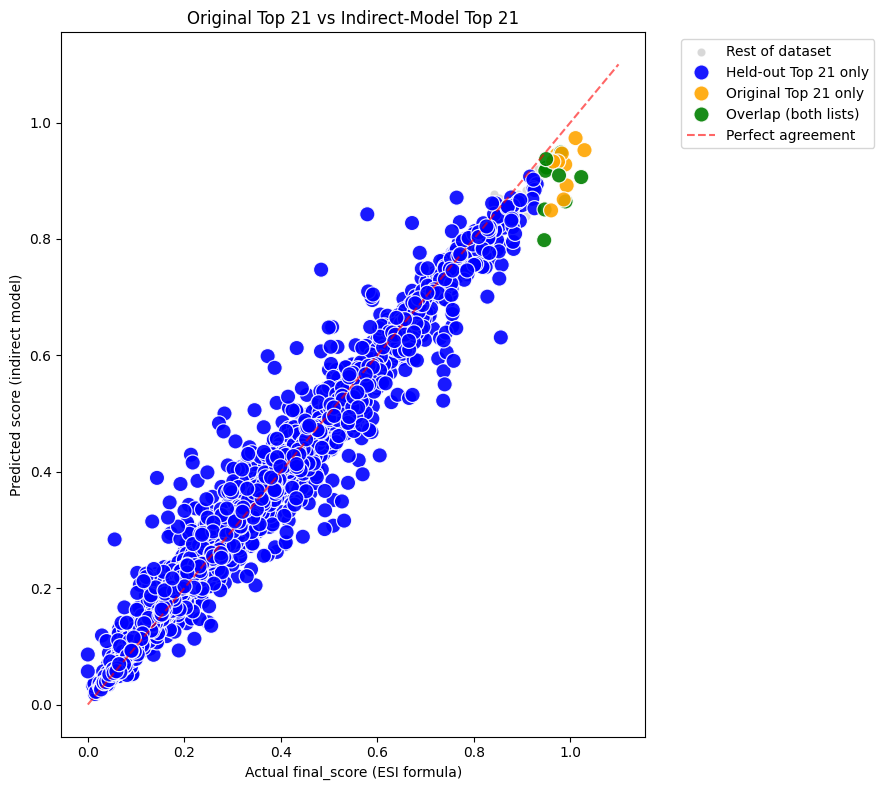

In [54]:
# Build a category label for every planet
def categorize(name):
    in_original = name in original_names
    in_held_out = name in held_out_names
    if in_original and in_held_out:
        return 'Overlap (both lists)'
    elif in_original:
        return 'Original Top 21 only'
    elif in_held_out:
        return 'Held-out Top 21 only'
    else:
        return 'Rest of dataset'

relevant_planets_data['comparison_group'] = relevant_planets_data['pl_name'].apply(categorize)

plt.figure(figsize=(9, 8))

# Background: everything else, faint
sns.scatterplot(
    data=relevant_planets_data[relevant_planets_data['comparison_group'] == 'Rest of dataset'],
    x='final_score', y='predicted_score_indirect', color='grey', alpha=0.3, label='Rest of dataset'
)

# Highlighted groups
palette = {'Original Top 21 only': 'orange', 'Held-out Top 21 only': 'blue', 'Overlap (both lists)': 'green'}
highlight_data = relevant_planets_data[relevant_planets_data['comparison_group'] != 'Rest of dataset']

sns.scatterplot(
    data=highlight_data, x='final_score', y='predicted_score_indirect',
    hue='comparison_group', palette=palette, s=120, alpha=0.9
)

plt.plot([0, 1.1], [0, 1.1], color='red', linestyle='--', alpha=0.6, label='Perfect agreement')
plt.xlabel('Actual final_score (ESI formula)')
plt.ylabel('Predicted score (indirect model)')
plt.title('Original Top 21 vs Indirect-Model Top 21')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
TOI_planets_data = pd.read_csv("TOI_2026.csv",sep=None,
    engine="python",
    comment="#")

In [56]:
TOI_planets_data

,rowid,toi,toipfx,tid,ctoi_alias,pl_pnum,tfopwg_disp,rastr,ra,raerr1,...,st_loggerr2,st_logglim,st_loggsymerr,st_rad,st_raderr1,st_raderr2,st_radlim,st_radsymerr,toi_created,rowupdate
0,1,1000.01,1000,50365310,5.036531e+07,1,FP,07h29m25.85s,112.357708,NaN,...,-0.07,0,1,2.169860,0.072573,-0.072573,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01
1,2,1001.01,1001,88863718,8.886372e+07,1,PC,08h10m19.31s,122.580465,NaN,...,-0.09,0,1,2.010000,0.090000,-0.090000,0,1,2019-07-24 15:58:33,2023-04-03 14:31:04
2,3,1002.01,1002,124709665,1.247097e+08,1,FP,06h58m54.47s,104.726966,NaN,...,NaN,0,1,5.730000,NaN,NaN,0,1,2019-07-24 15:58:33,2022-07-11 16:02:02
3,4,1003.01,1003,106997505,1.069975e+08,1,FP,07h22m14.39s,110.559945,NaN,...,-1.64,0,1,NaN,NaN,NaN,0,1,2019-07-24 15:58:33,2022-02-23 10:10:02
4,5,1004.01,1004,238597883,2.385979e+08,1,FP,08h08m42.77s,122.178195,NaN,...,-0.07,0,1,2.150000,0.060000,-0.060000,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,8060,995.01,995,317951248,3.179512e+08,1,FP,07h23m14.75s,110.811443,NaN,...,NaN,0,1,NaN,NaN,NaN,0,1,2019-07-24 15:58:33,2021-10-29 12:59:15
8060,8061,996.01,996,142918609,1.429186e+08,1,FP,07h57m23.99s,119.349948,NaN,...,NaN,0,1,2.050000,NaN,NaN,0,1,2019-07-24 15:58:33,2021-10-29 12:59:15
8061,8062,997.01,997,341729521,3.417295e+08,1,FP,08h05m16.69s,121.319521,NaN,...,-0.08,0,1,0.926261,0.045789,-0.045789,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01
8062,8063,998.01,998,54390047,5.439005e+07,1,FP,07h53m16.69s,118.319555,NaN,...,-0.07,0,1,2.349860,0.091578,-0.091578,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01


In [57]:
TOI_planets_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 87 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              8064 non-null   int64  
 1   toi                8064 non-null   float64
 2   toipfx             8064 non-null   int64  
 3   tid                8064 non-null   int64  
 4   ctoi_alias         8064 non-null   float64
 5   pl_pnum            8064 non-null   int64  
 6   tfopwg_disp        8061 non-null   str    
 7   rastr              8064 non-null   str    
 8   ra                 8064 non-null   float64
 9   raerr1             0 non-null      float64
 10  raerr2             0 non-null      float64
 11  decstr             8064 non-null   str    
 12  dec                8064 non-null   float64
 13  decerr1            0 non-null      float64
 14  decerr2            0 non-null      float64
 15  st_pmra            7929 non-null   float64
 16  st_pmraerr1        7929 non-null   

In [58]:
TOI_planets_data.shape

(8064, 87)

In [59]:
candidate_compatible_features = ['pl_orbper', 'st_teff', 'sy_dist']

X_compat = relevant_planets_data[candidate_compatible_features]
Y_compat = relevant_planets_data['final_score']

X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(X_compat, Y_compat, test_size=0.2, random_state=42)

rf_compat = RandomForestRegressor(n_estimators=200, random_state=42)
rf_compat.fit(X_train_c, Y_train_c)
preds_compat = rf_compat.predict(X_test_c)

print("R²:", r2_score(Y_test_c, preds_compat))
print("RMSE:", np.sqrt(mean_squared_error(Y_test_c, preds_compat)))

R²: 0.8110037989756291
RMSE: 0.0821020594345725


In [60]:
TOI_relevant_test_data = TOI_planets_data[TOI_planets_data['tfopwg_disp'].isin(['PC', 'APC'])]

In [61]:
TOI_relevant_test_data.shape

(5381, 87)

In [62]:
TOI_relevant_test_data = TOI_relevant_test_data.rename(columns = {'st_dist': 'sy_dist'})

In [63]:
TOI_Features = TOI_relevant_test_data[['pl_orbper', 'st_teff', 'sy_dist']].copy()

In [64]:
TOI_Features

,pl_orbper,st_teff,sy_dist
1,1.931646,7070.0,295.862
7,6.998921,6596.0,283.291
9,1.960028,8868.7,866.147
12,2.470504,5413.7,52.620
13,0.884182,8928.0,295.959
...,...,...,...
8042,13.166014,6368.0,291.631
8053,3.121181,7814.0,476.811
8054,4.587386,8388.0,465.990
8055,2.484323,9855.0,616.305


In [65]:
TOI_Features.isna().sum()

pl_orbper     73
st_teff      131
sy_dist      162
dtype: int64

In [66]:
TOI_Features_cleaned = TOI_Features.dropna()

In [67]:
TOI_Features_cleaned

,pl_orbper,st_teff,sy_dist
1,1.931646,7070.0,295.862
7,6.998921,6596.0,283.291
9,1.960028,8868.7,866.147
12,2.470504,5413.7,52.620
13,0.884182,8928.0,295.959
...,...,...,...
8042,13.166014,6368.0,291.631
8053,3.121181,7814.0,476.811
8054,4.587386,8388.0,465.990
8055,2.484323,9855.0,616.305


In [68]:
TOI_Features_cleaned.shape

(5039, 3)

In [69]:
TOI_relevant_test_data = TOI_relevant_test_data.loc[TOI_Features_cleaned.index]

TOI_relevant_test_data['predicted_score'] = rf_compat.predict(TOI_Features_cleaned)

top_toi_candidates = TOI_relevant_test_data.sort_values('predicted_score', ascending=False)

top_toi_candidates[['toi', 'tid', 'pl_orbper', 'st_teff', 'sy_dist', 'predicted_score']].head(21)

,toi,tid,pl_orbper,st_teff,sy_dist,predicted_score
7254,7347.01,233747840,60.834488,3736.0,227.3370,0.881742
4945,5311.01,306401382,39.053693,3793.0,243.3200,0.879817
7303,7390.01,160075684,81.371668,3861.0,61.7605,0.870284
7005,7125.01,272829240,21.727664,3437.0,115.0610,0.862823
1304,2094.01,356016119,18.793175,3457.0,50.0248,0.849429
7566,7622.01,141279435,40.821652,3919.0,250.9610,0.843739
4186,4632.01,336075472,63.144852,4152.0,65.4707,0.843048
4029,450.01,77951245,10.714866,3054.0,53.5063,0.837059
7852,798.01,260640693,95.239176,4270.0,121.0520,0.835594
7452,7522.01,459021929,21.726251,3318.0,162.6460,0.835283


In [70]:
# import joblib

In [71]:
# joblib.dump(rf_indirect2, 'rf_indirect_model.pkl')  # primary indirect model (0.9171 R²)
# joblib.dump(rf_compat, 'rf_compat_model.pkl')        # candidate-compatible model (0.81 R², for real unconfirmed candidates)

In [72]:
relevant_planets_data[['pl_name', 'pl_rade', 'pl_insol', 'star_class', 'final_score']].to_csv('planets_for_app.csv', index=False)

In [73]:
top_toi_candidates[['toi', 'pl_orbper', 'st_teff', 'sy_dist', 'predicted_score']].to_csv('toi_for_app.csv', index=False)

In [76]:
relevant_planets_data['discoverymethod'].value_counts()

discoverymethod
Transit                          4435
Radial Velocity                  1114
Transit Timing Variations          32
Imaging                            18
Eclipse Timing Variations           7
Astrometry                          3
Orbital Brightness Modulation       3
Pulsation Timing Variations         1
Name: count, dtype: int64